# **01 - Linear Regression**

This notebook constructs a multiple linear regression (MLR) model based on real estate valuation from Taipei, Taiwan for an 11-month period from 2012 to 2013. The data contains 6 features with Y being the Price Per Area (Unit of measurement).

## ****Libraries****

In [26]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

## **Data Loading**

In [75]:
df = pd.read_excel('datasets/Real estate valuation data set.xlsx')
x_train_np = 'placeholder'
y_train_np = 'placeholder'

# Convert NumPy data into Tensor Data
x_train = 'placeholder'
y_train = 'placeholder'

## **Exploratory Data Analysis and Visualization**

In [107]:
# Summary Statistics
df.describe()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,207.500000,2013.148953,17.712560,1083.885689,4.094203,24.969030,121.533361,37.980193
std,119.655756,0.281995,11.392485,1262.109595,2.945562,0.012410,0.015347,13.606488
min,1.000000,2012.666667,0.000000,23.382840,0.000000,24.932070,121.473530,7.600000
25%,104.250000,2012.916667,9.025000,289.324800,1.000000,24.963000,121.528085,27.700000
50%,207.500000,2013.166667,16.100000,492.231300,4.000000,24.971100,121.538630,38.450000
75%,310.750000,2013.416667,28.150000,1454.279000,6.000000,24.977455,121.543305,46.600000
max,414.000000,2013.583333,43.800000,6488.021000,10.000000,25.014590,121.566270,117.500000


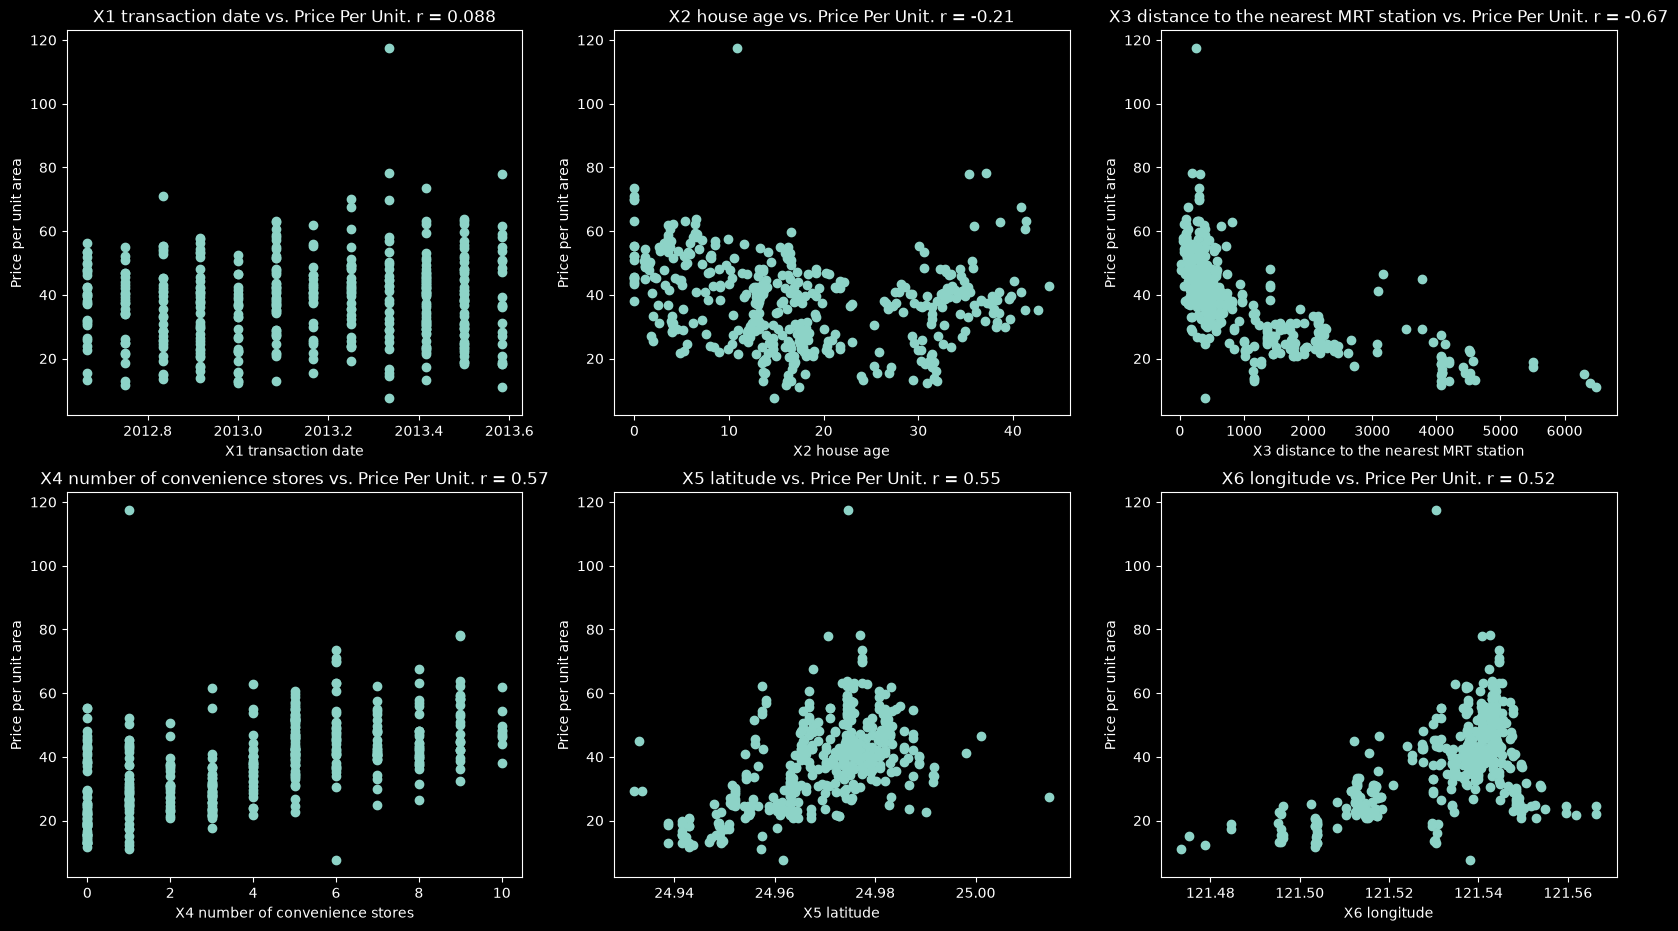

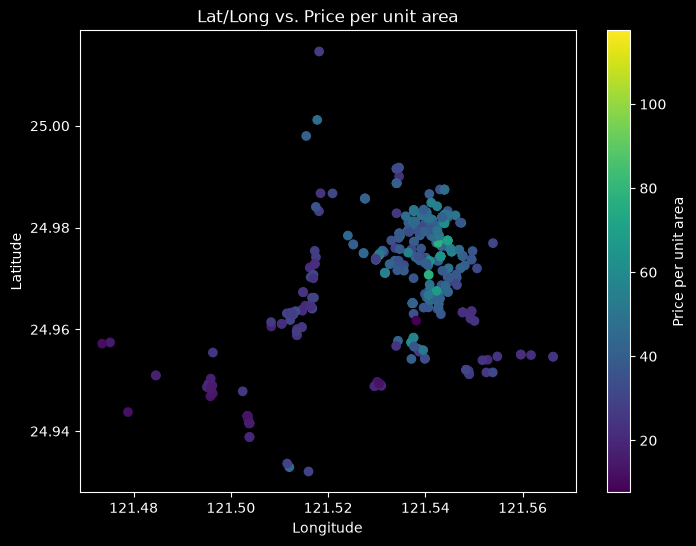

In [142]:
# Scatter Plots
fig, ax = plt.subplots(2, 3, figsize = (20, 11))
ax = ax.flatten()

features = []
for f in df.columns[1:-1]:
    features.append(f)

for i, feature in enumerate(features):
    r = df[feature].corr(df['Y house price of unit area'])
    ax[i].scatter(df[feature], df['Y house price of unit area'])
    ax[i].set_title(f"{feature} vs. Price Per Unit. r = {r:.2}")
    ax[i].set_xlabel(feature)
    ax[i].set_ylabel('Price per unit area')

plt.figure(figsize = (8, 6))
plt.scatter(df['X6 longitude'],
           df['X5 latitude'],
           c=df['Y house price of unit area']
            )
r = df[feature].corr(df['Y house price of unit area'])
plt.title('Lat/Long vs. Price per unit area')
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.colorbar(label = "Price per unit area")


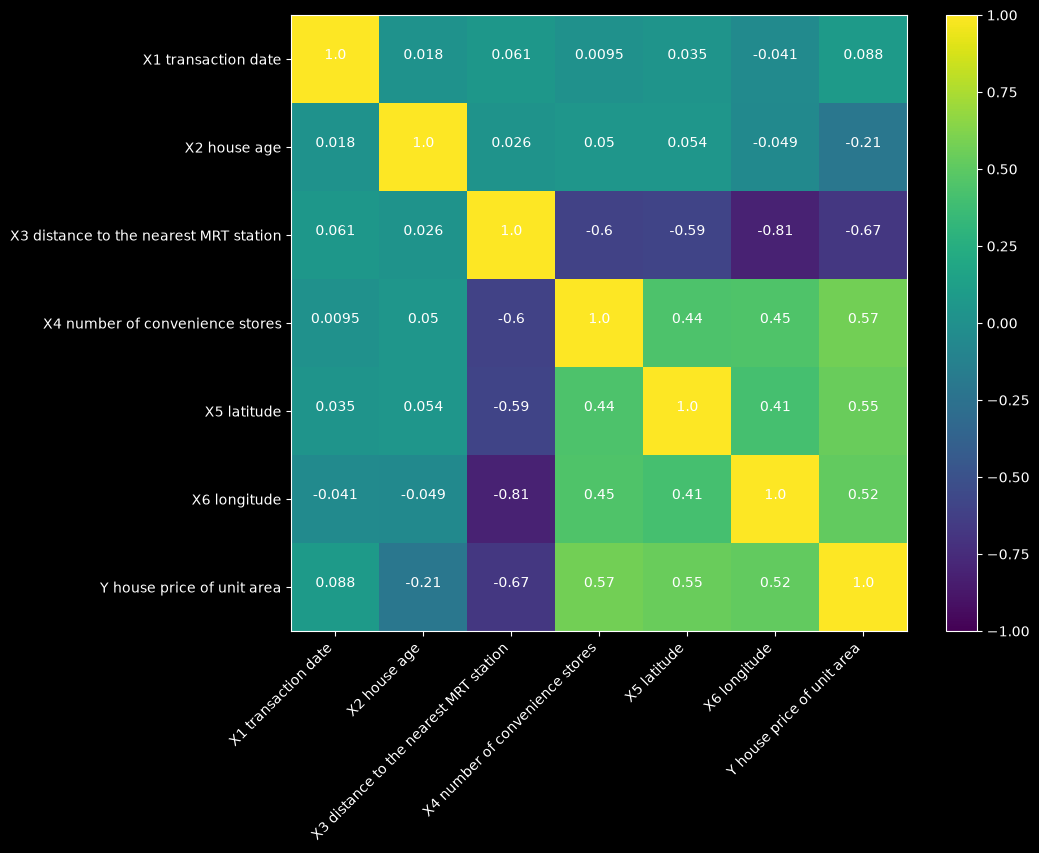

In [140]:
# Correlation Matrix
corr_matrix = df.drop(columns=['No']).corr()

fig, ax = plt.subplots(figsize = (10, 8))
image = ax.imshow(corr_matrix, vmin=-1, vmax=1)
plt.colorbar(image, ax=ax)

# Axis Labels
ax.set_xticks(range(7))
ax.set_xticklabels(corr_matrix.columns, rotation = 45, ha = 'right')

ax.set_yticks(range(7))
ax.set_yticklabels(corr_matrix.columns)

# Individual r values
for row in range(len(corr_matrix)):
    for col in range(len(corr_matrix)):
        r = corr_matrix.iloc[row, col]
        ax.text(row, col, f"{r:.2}", ha="center")

### **Initial Findings**

The correlation matrix appears to indicate that MRT proximity, increased shopping locations, and higher prices may define a Desirable Location.

## **Model**

### **Model Architecture**

In [ ]:
# Linear Regression Architecture

class LR(nn.Module):
    def __init__(self, input_features):
        super().__init__()
        self.linear_stack = nn.Sequential(
            nn.Linear(input_features, 1)
        )

    def forward(self, data):
        prediction = self.linear_stack(data)
        return prediction

# Instance, Loss Function, Optimizer

model = LR() # Specify number of features

loss_function = nn.MSELoss()

optimizer = torch.optim.SGD(model.parameters(),lr=1e-2) #Stochastic Grad. Descent

### **Model Training**

In [ ]:
loss_list = []
nums_epoch = 2000 # Epoch is one complete pass through the training set

for epoch in range(nums_epoch):

    prediction = model(x_train) # Takes x training data, produces new yhat with current parameters
    loss = loss_function(prediction, y_train) # Cost/Loss function calculation

    # Gradient Descent
    optimizer.zero_grad() # Clear current gradient information
    loss.backward() # Backprop - calculate partial derivatives based on current loss with respect to each contributing parameter
    optimizer.step() # Calculate the new weights based on step/learning rate

    if epoch % 100 == 0:
        print('epoch = ', epoch, ' current loss = ', loss.item())

### **Test Data Prediction**